In [27]:
import random
import os
import numpy as np
import torch

def seed_everything(seed):
    """
    """
    # 1. Python & Numpy
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

    # 2. PyTorch (CPU & GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"🔒 Locked Random Seed: {seed}")



In [28]:
import torch
import numpy as np
import random

def seed_everything_random():
    """
    Tạo random seed, set seed đó, và return seed để bạn biết
    """
    # Tạo random seed
    random_seed = random.randint(0, 999999)

    # Set seed
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)
    np.random.seed(random_seed)
    random.seed(random_seed)

    # Để reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    return random_seed


In [29]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import gc

def clear_memory():
    gc.collect()
    torch.cuda.empty_cache()

In [30]:
#load data
df_men = pd.read_csv(r"/home/ducvu0904/Documents/Lab/RERUM/dataset/Hillstrom-Men.csv")
df_men = df_men.drop(columns="Unnamed: 0")
print ("---------------------------")
print ("null count:")
print (df_men.isnull().sum())
print ("---------------------------")
print(df_men.dtypes)
print ("---------------------------")
print ("labels:")
print(df_men.columns.tolist())
print ("---------------------------")
print("data shape:")
print(df_men.shape)

df_men_edit = df_men[df_men["spend"] != 29.99]

---------------------------
null count:
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
visit              0
conversion         0
spend              0
treatment          0
dtype: int64
---------------------------
recency              int64
history_segment        str
history            float64
mens                 int64
womens               int64
zip_code               str
newbie               int64
channel                str
visit                int64
conversion           int64
spend              float64
treatment            int64
dtype: object
---------------------------
labels:
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'visit', 'conversion', 'spend', 'treatment']
---------------------------
data shape:
(42613, 12)


In [31]:
#Hillstrom-men
#split num and cate
cate_cols = ['zip_code', 'channel', 'history_segment']
num_cols = ['recency', 'history']

#split x y t
y_men = df_men["spend"]
t_men = df_men["treatment"]
x_men = df_men.drop(columns=["spend", "treatment", "visit", "conversion"])

# Tạo biến stratify kết hợp: treatment x purchase (y > 0)
stratify_combined = t_men.astype(str) + "_" + (y_men > 0).astype(int).astype(str)

#train test split - stratify bằng treatment x purchase
x_men_train, x_men_test, t_men_train, t_men_test, y_men_train, y_men_test = train_test_split(
    x_men, t_men.values, y_men.values,
    test_size=0.3, random_state=42, stratify=stratify_combined
)

# Tạo stratify cho val split - treatment x purchase
stratify_var_train = pd.Series(t_men_train).astype(str) + "_" + (pd.Series(y_men_train) > 0).astype(int).astype(str)

x_men_train, x_men_val, t_men_train, t_men_val, y_men_train, y_men_val = train_test_split(
    x_men_train, t_men_train, y_men_train,
    test_size=(1/7), random_state=42, stratify=stratify_var_train
)

# y_men_train = np.log1p(y_men_train)
# y_men_val = np.log1p(y_men_val)

# Fit get_dummies trên train, sau đó align với val/test
x_men_train_encode = pd.get_dummies(x_men_train, columns=cate_cols, drop_first=False)
x_men_val_encode = pd.get_dummies(x_men_val, columns=cate_cols, drop_first=False)
x_men_test_encode = pd.get_dummies(x_men_test, columns=cate_cols, drop_first=False)

# Align columns
x_men_val_encode = x_men_val_encode.reindex(columns=x_men_train_encode.columns, fill_value=0)
x_men_test_encode = x_men_test_encode.reindex(columns=x_men_train_encode.columns, fill_value=0)

scaler = StandardScaler()
x_men_train= scaler.fit_transform(x_men_train_encode)
x_men_val = scaler.transform(x_men_val_encode)
x_men_test = scaler.transform(x_men_test_encode)

print ("✅ Train/Val/Test split with stratification by TREATMENT x PURCHASE")
print (f"Train: {x_men_train.shape}, Val: {x_men_val.shape}, Test: {x_men_test.shape}")
print (f"Treatment distribution - Train: {np.mean(t_men_train):.2%}, Val: {np.mean(t_men_val):.2%}, Test: {np.mean(t_men_test):.2%}")
print (f"Purchase rate - Train: {np.mean(y_men_train > 0):.2%}, Val: {np.mean(y_men_val > 0):.2%}, Test: {np.mean(y_men_test > 0):.2%}")
print (f"Spend mean - Train: {np.mean(y_men_train):.2f}, Val: {np.mean(y_men_val):.2f}, Test: {np.mean(y_men_test):.2f}")

✅ Train/Val/Test split with stratification by TREATMENT x PURCHASE
Train: (25567, 18), Val: (4262, 18), Test: (12784, 18)
Treatment distribution - Train: 50.00%, Val: 50.00%, Test: 50.00%
Purchase rate - Train: 0.91%, Val: 0.92%, Test: 0.92%
Spend mean - Train: 1.06, Val: 1.05, Test: 0.99


In [32]:
#Transform to tensor
def to_tensor(df):
    return torch.tensor(df, dtype=torch.float32)
batch_size = 6400

x_men_train_t = to_tensor(x_men_train)
x_men_val_t = to_tensor(x_men_val)
x_men_test_t = to_tensor(x_men_test)

y_men_train_t = to_tensor(y_men_train).unsqueeze(1)
y_men_val_t = to_tensor(y_men_val).unsqueeze(1)
y_men_test_t = to_tensor(y_men_test).unsqueeze(1)

t_men_train_t = to_tensor(t_men_train.astype(float)).unsqueeze(1)
t_men_val_t = to_tensor(t_men_val.astype(float)).unsqueeze(1)
t_men_test_t = to_tensor(t_men_test.astype(float)).unsqueeze(1)

#Data loader
train_dataset = TensorDataset(x_men_train_t, t_men_train_t, y_men_train_t)
val_dataset = TensorDataset(x_men_val_t, t_men_val_t, y_men_val_t)
test_dataset = TensorDataset(x_men_test_t, t_men_test_t, y_men_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print ("-------------------------------------------------------------")
print ("✅Completed tranform to tensor✅")
print (f"Shape of train: x={x_men_train_t.shape}; y ={y_men_train_t.shape}; t={t_men_train_t.shape}")
print (f"Shape of val: x={x_men_val_t.shape}; y={y_men_val_t.shape}; t={t_men_val_t.shape}")
print (f"Shape of test: x={x_men_test_t.shape}; y={y_men_test_t.shape}; t={t_men_test_t.shape}")

-------------------------------------------------------------
✅Completed tranform to tensor✅
Shape of train: x=torch.Size([25567, 18]); y =torch.Size([25567, 1]); t=torch.Size([25567, 1])
Shape of val: x=torch.Size([4262, 18]); y=torch.Size([4262, 1]); t=torch.Size([4262, 1])
Shape of test: x=torch.Size([12784, 18]); y=torch.Size([12784, 1]); t=torch.Size([12784, 1])


In [33]:
print("First 5 samples after preprocessing (one-hot encoded train features):")
print(x_men_train_encode.head())

print("\nFirst 5 samples after scaling (train features):")
x_men_train_scaled_df = pd.DataFrame(x_men_train, columns=x_men_train_encode.columns)
print(x_men_train_scaled_df.head())

First 5 samples after preprocessing (one-hot encoded train features):
       recency  history  mens  womens  newbie  zip_code_Rural  \
11023        5   513.05     1       0       1           False   
40450        1   548.54     1       0       1           False   
6679        10   335.22     1       0       1           False   
11345       10   263.65     1       1       0           False   
16138        1   240.79     0       1       0           False   

       zip_code_Surburban  zip_code_Urban  channel_Multichannel  \
11023               False            True                  True   
40450               False            True                  True   
6679                False            True                  True   
11345                True           False                  True   
16138               False            True                 False   

       channel_Phone  channel_Web  history_segment_1) $0 - $100  \
11023          False        False                         False   
40

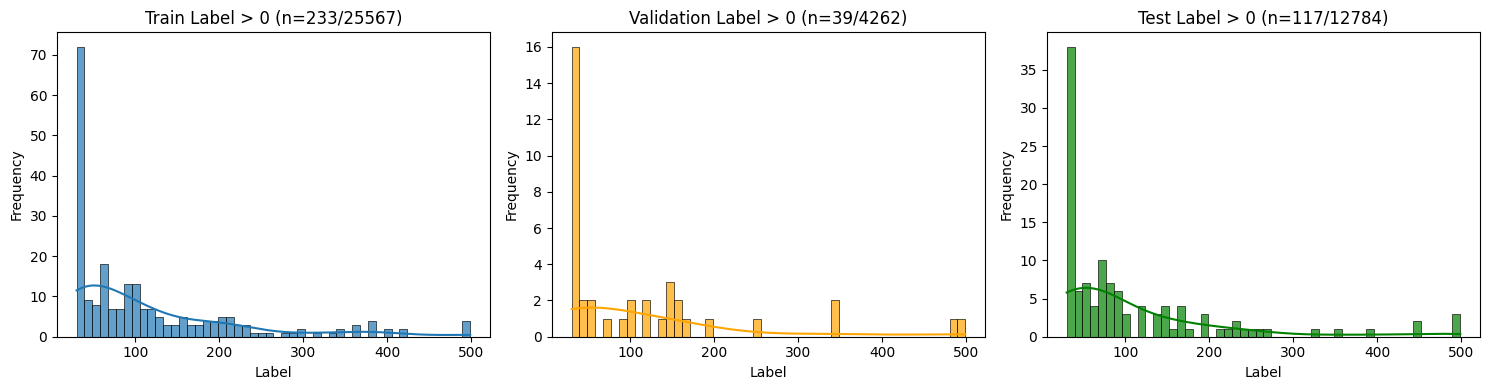

Train (>0) - Mean: 116.2666, Std: 107.2064, Min: 29.9900, Max: 499.0000
Val   (>0) - Mean: 114.2933, Std: 119.1547, Min: 29.9900, Max: 499.0000
Test  (>0) - Mean: 108.3117, Std: 108.0414, Min: 29.9900, Max: 499.0000


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only values > 0
y_train_pos = y_men_train[y_men_train > 0]
y_val_pos = y_men_val[y_men_val > 0]
y_test_pos = y_men_test[y_men_test > 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Train
sns.histplot(y_train_pos, bins=50, kde=True, ax=axes[0], alpha=0.7, edgecolor='black')
axes[0].set_title(f'Train Label > 0 (n={len(y_train_pos)}/{len(y_men_train)})')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Frequency')

# Validation
sns.histplot(y_val_pos, bins=50, kde=True, ax=axes[1], alpha=0.7, color='orange', edgecolor='black')
axes[1].set_title(f'Validation Label > 0 (n={len(y_val_pos)}/{len(y_men_val)})')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Frequency')

# Test
sns.histplot(y_test_pos, bins=50, kde=True, ax=axes[2], alpha=0.7, color='green', edgecolor='black')
axes[2].set_title(f'Test Label > 0 (n={len(y_test_pos)}/{len(y_men_test)})')
axes[2].set_xlabel('Label')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Train (>0) - Mean: {y_train_pos.mean():.4f}, Std: {y_train_pos.std():.4f}, Min: {y_train_pos.min():.4f}, Max: {y_train_pos.max():.4f}")
print(f"Val   (>0) - Mean: {y_val_pos.mean():.4f}, Std: {y_val_pos.std():.4f}, Min: {y_val_pos.min():.4f}, Max: {y_val_pos.max():.4f}")
print(f"Test  (>0) - Mean: {y_test_pos.mean():.4f}, Std: {y_test_pos.std():.4f}, Min: {y_test_pos.min():.4f}, Max: {y_test_pos.max():.4f}")

In [35]:
def compute_ate(y, t):
    y = np.asarray(y).reshape(-1)
    t = np.asarray(t).reshape(-1)
    treated = y[t == 1]
    control = y[t == 0]
    return treated.mean() - control.mean()

ate_train = compute_ate(y_men_train, t_men_train)
ate_val = compute_ate(y_men_val, t_men_val)
ate_test = compute_ate(y_men_test, t_men_test)

print(f"ATE (Train): {ate_train:.6f}")
print(f"ATE (Val):   {ate_val:.6f}")
print(f"ATE (Test):  {ate_test:.6f}")

ATE (Train): 0.828667
ATE (Val):   0.963970
ATE (Test):  0.587423


In [36]:
from metrics import auuc, auqc, lift, krcc

In [37]:
from dragonnet import Dragonnet

In [38]:
print("📊 Data Distribution Check:")
print(f"Y train: mean={y_men_train.mean():.4f}, std={y_men_train.std():.4f}")
print(f"Y train zeros: {(y_men_train == 0).sum()} / {len(y_men_train)} ({(y_men_train == 0).sum()/len(y_men_train)*100:.1f}%)")
print(f"\nTreatment balance:")
print(f"  Train: {(t_men_train == 1).sum()} treated, {(t_men_train == 0).sum()} control")
print(f"  Test:  {(t_men_test == 1).sum()} treated, {(t_men_test == 0).sum()} control")

📊 Data Distribution Check:
Y train: mean=1.0596, std=15.0603
Y train zeros: 25334 / 25567 (99.1%)

Treatment balance:
  Train: 12784 treated, 12783 control
  Test:  6392 treated, 6392 control


In [39]:
epochs = 150
alpha = 1 
beta = 1
lr = 1e-4
wd = 1e-4
early_stop_metric = "qini"
ema = True
ema_alpha = 0.05
patience = 15
shared_dropout = 0
outcome_droupout = 0 
shared_hidden = 200
outcome_hidden = 100
early_stop_start = 0

print (f" epochs = {epochs}")
print (f" alpha = {alpha}")
print (f" beta = {beta}")
print (f" learning rate = {lr}")
print (f" weight decay = {wd}")
print (f" early stop = {early_stop_metric}")
print (f" use ema = {ema}")
print (f" ema alpha = {ema_alpha}")
print (f" patience = {patience}")
print (f" share dropout = {shared_dropout}")
print (f" outcome dropout = {outcome_droupout}")
print (f" shared hidden = {shared_hidden}")
print (f" outcome hidden = {outcome_hidden}")

 epochs = 150
 alpha = 1
 beta = 1
 learning rate = 0.0001
 weight decay = 0.0001
 early stop = qini
 use ema = True
 ema alpha = 0.05
 patience = 15
 share dropout = 0
 outcome dropout = 0
 shared hidden = 200
 outcome hidden = 100


🔒 Locked Random Seed: 412312
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.05)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini


Epoch 1/150 | Base Loss: 51.5808 | Tarreg Loss: 254.990189 | Total Loss: 306.5710 | Val Loss: 49.5928 | Raw Qini: 0.5671 | EMA Trend: 0.5671 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/150 | Base Loss: 51.5745 | Tarreg Loss: 268.214661 | Total Loss: 319.7891 | Val Loss: 48.8020 | Raw Qini: 0.4721 | EMA Trend: 0.5624 | (patience: 1/15)
Epoch 3/150 | Base Loss: 47.4889 | Tarreg Loss: 149.274292 | Total Loss: 196.7632 | Val Loss: 47.9983 | Raw Qini: 0.4188 | EMA Trend: 0.5552 | (patience: 2/15)
Epoch 4/150 | Base Loss: 48.0130 | Tarreg Loss: 165.685699 | Total Loss: 213.6987 | Val Loss: 47.1292 | Raw Qini: 0.3880 | EMA Trend: 0.5468 | (patience: 3/15)
Epoch 5/150 | Base Loss: 44.9911 | Tarreg Loss: 176.638702 | Total Loss: 221.6298 | Val Loss: 46.1666 | Raw Qini: 0.3777 | EMA Trend: 0.5384 | (patience: 4/15)
Epoch 6/150 | Base Loss: 46.2723 | Tarreg Loss: 324.401642 | Total Loss: 370.6740 | Val Loss: 45.0885 | Raw Qini: 0.3742 | EMA Trend: 0.5302 | (patience: 5/15)
Epoch 7/150 | Base Loss: 44.707

/home/ducvu0904/Documents/Lab/RERUM/Dragonnet + ZILN/dragonnet.py:333: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


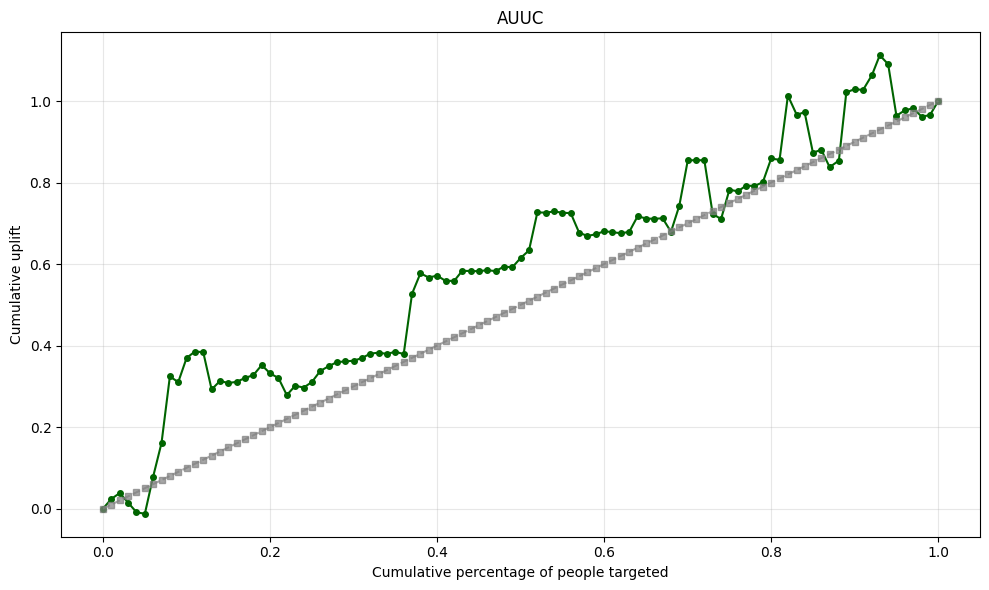

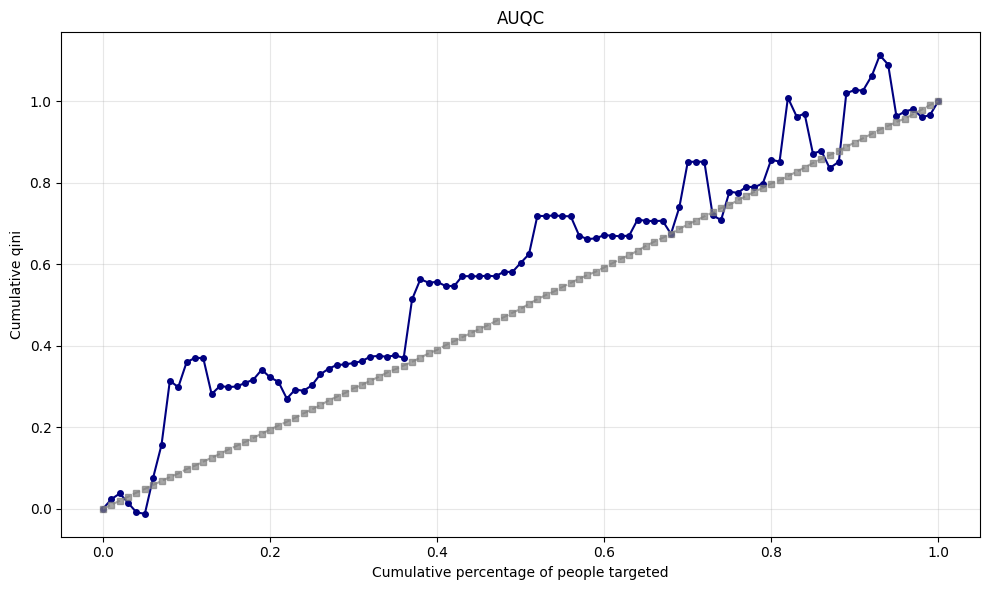

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.593
AUQC: 0.586
Lift: 0.710
KRCC: 0.022


In [40]:
seed = 412312
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_dropout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")

🔒 Locked Random Seed: 42
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.05)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/150 | Base Loss: 47.0418 | Tarreg Loss: 255.111374 | Total Loss: 302.1532 | Val Loss: 45.4508 | Raw Qini: 0.3707 | EMA Trend: 0.3707 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/150 | Base Loss: 45.4970 | Tarreg Loss: 233.445480 | Total Loss: 278.9424 | Val Loss: 44.6722 | Raw Qini: 0.4345 | EMA Trend: 0.3739 | ⭐ NEW BEST (peak ≥ trend)


Epoch 3/150 | Base Loss: 44.3953 | Tarreg Loss: 217.802338 | Total Loss: 262.1977 | Val Loss: 43.9137 | Raw Qini: 0.4624 | EMA Trend: 0.3783 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/150 | Base Loss: 48.3272 | Tarreg Loss: 316.438812 | Total Loss: 364.7660 | Val Loss: 43.1614 | Raw Qini: 0.4612 | EMA Trend: 0.3825 | ✓ above trend but not peak (patience: 1/15)
Epoch 5/150 | Base Loss: 43.0085 | Tarreg Loss: 233.715683 | Total Loss: 276.7242 | Val Loss: 42.3623 | Raw Qini: 0.4377 | EMA Trend: 0.3852 | ✓ above trend but not peak (patience: 2/15)
Epoch 6/150 | Base Loss: 42.4961 | Tarreg Loss: 198.460052 | Total Loss: 240.9562 | Val Loss: 41.4533 | Raw Qini: 0.4745 | EMA Trend: 0.3897 | ⭐ NEW BEST (peak ≥ trend)
Epoch 7/150 | Base Loss: 42.0190 | Tarreg Loss: 214.000702 | Total Loss: 256.0197 | Val Loss: 40.3928 | Raw Qini: 0.5115 | EMA Trend: 0.3958 | ⭐ NEW BEST (peak ≥ trend)
Epoch 8/150 | Base Loss: 40.2985 | Tarreg Loss: 151.879944 | Total Loss: 192.1785 | Val Loss: 39.1889 | Raw Qini: 0.550

/home/ducvu0904/Documents/Lab/RERUM/Dragonnet + ZILN/dragonnet.py:333: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


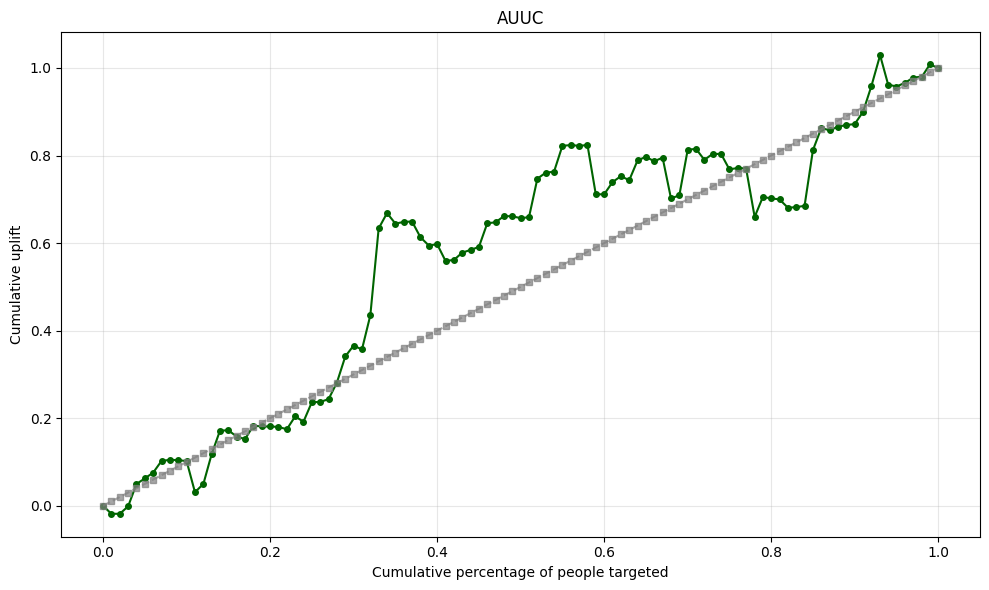

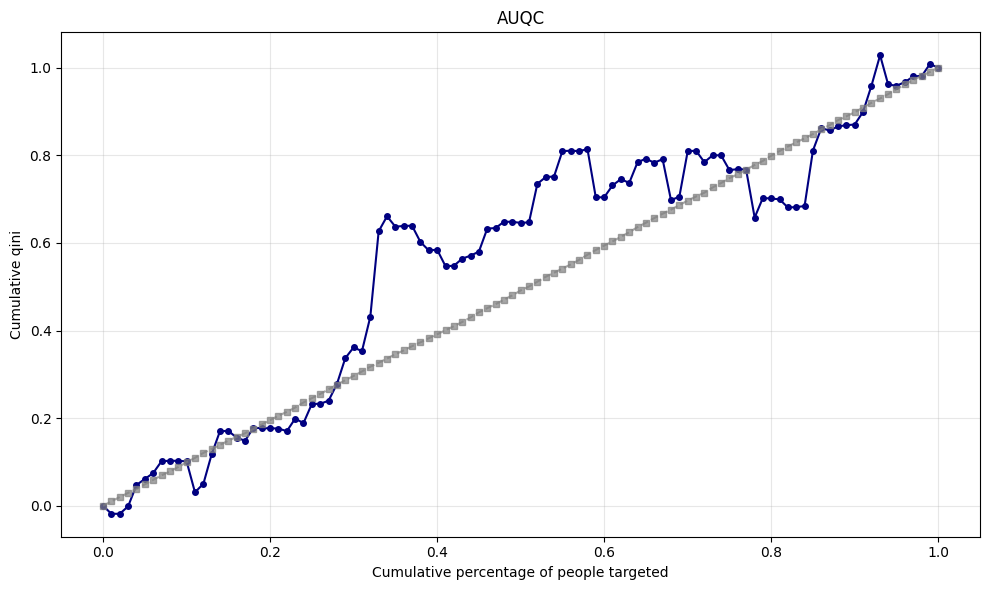

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.564
AUQC: 0.559
Lift: 0.716
KRCC: 0.029


In [41]:
seed = 42
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_dropout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")

🔒 Locked Random Seed: 1874
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.05)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/150 | Base Loss: 45.6273 | Tarreg Loss: 212.206451 | Total Loss: 257.8338 | Val Loss: 45.2264 | Raw Qini: 0.4179 | EMA Trend: 0.4179 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/150 | Base Loss: 44.7684 | Tarreg Loss: 130.123169 | Total Loss: 174.8916 | Val Loss: 44.4723 | Raw Qini: 0.4368 | EMA Trend: 0.4188 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/150 | Base Loss: 44.9422 | Tarreg Loss: 190.675964 | Total Loss: 235.6182 | Val Loss: 43.6967 | Raw Qini: 0.4227 | EMA Trend: 0.4190 | ✓ above trend but not peak (patience: 1/15)
Epoch 4/150 | Base Loss: 43.8701 | Tarreg Loss: 269.546692 | Total Loss: 313.4167 | Val Loss: 42.8690 | Raw Qini: 0.4127 | EMA Trend: 0.4187 | (patience: 2/15)
Epoch 5/150 | Base Loss: 42.8

/home/ducvu0904/Documents/Lab/RERUM/Dragonnet + ZILN/dragonnet.py:333: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


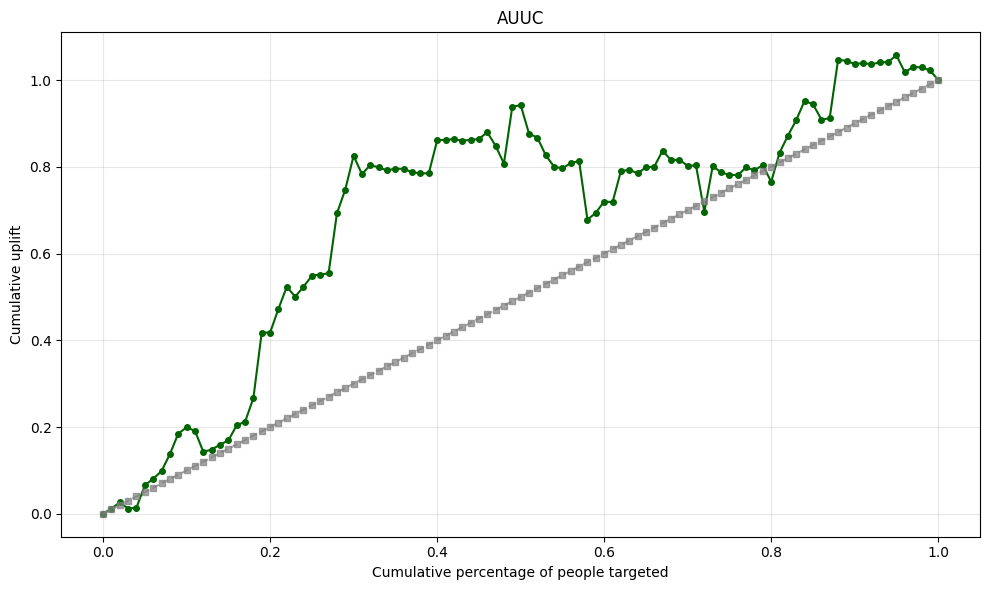

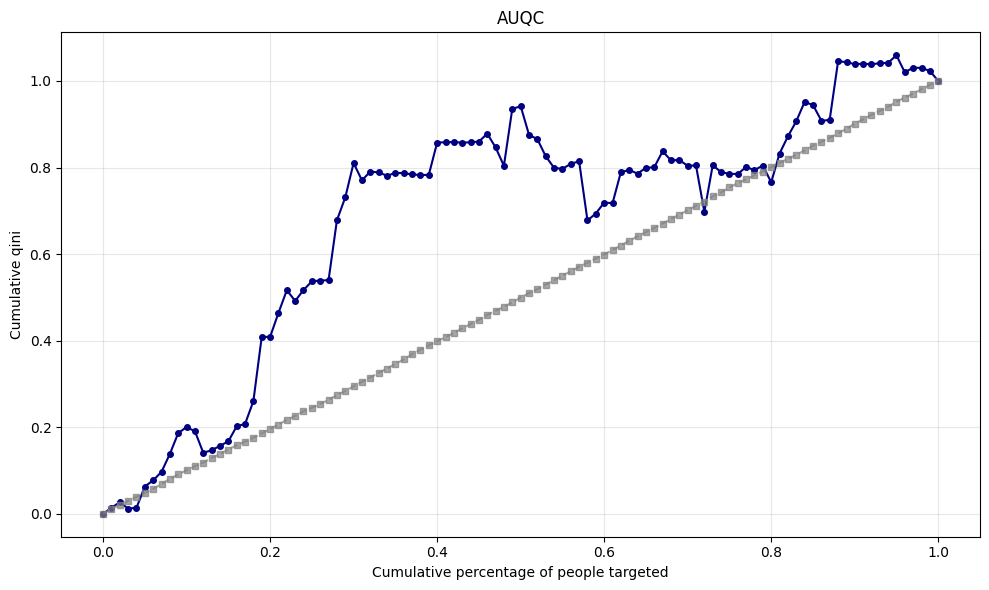

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.687
AUQC: 0.685
Lift: 1.616
KRCC: 0.152


In [42]:
seed = 1874
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_dropout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")


🔒 Locked Random Seed: 902745
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.05)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini


Epoch 1/150 | Base Loss: 45.9126 | Tarreg Loss: 180.202179 | Total Loss: 226.1148 | Val Loss: 45.0780 | Raw Qini: 0.6090 | EMA Trend: 0.6090 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/150 | Base Loss: 45.0877 | Tarreg Loss: 285.973022 | Total Loss: 331.0608 | Val Loss: 44.4528 | Raw Qini: 0.6415 | EMA Trend: 0.6106 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/150 | Base Loss: 46.1497 | Tarreg Loss: 222.013885 | Total Loss: 268.1636 | Val Loss: 43.7752 | Raw Qini: 0.6890 | EMA Trend: 0.6145 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/150 | Base Loss: 42.0495 | Tarreg Loss: 170.657303 | Total Loss: 212.7068 | Val Loss: 43.0226 | Raw Qini: 0.7149 | EMA Trend: 0.6196 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/150 | Base Loss: 47.7930 | Tarreg Loss: 267.990662 | Total Loss: 315.7837 | Val Loss: 42.1592 | Raw Qini: 0.7187 | EMA Trend: 0.6245 | ⭐ NEW BEST (peak ≥ trend)
Epoch 6/150 | Base Loss: 39.3800 | Tarreg Loss: 182.400955 | Total Loss: 221.7809 | Val Loss: 41.1308 | Raw Qini: 0.7350 | EMA Trend: 0.6300 | ⭐ NEW BEST (

/home/ducvu0904/Documents/Lab/RERUM/Dragonnet + ZILN/dragonnet.py:333: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


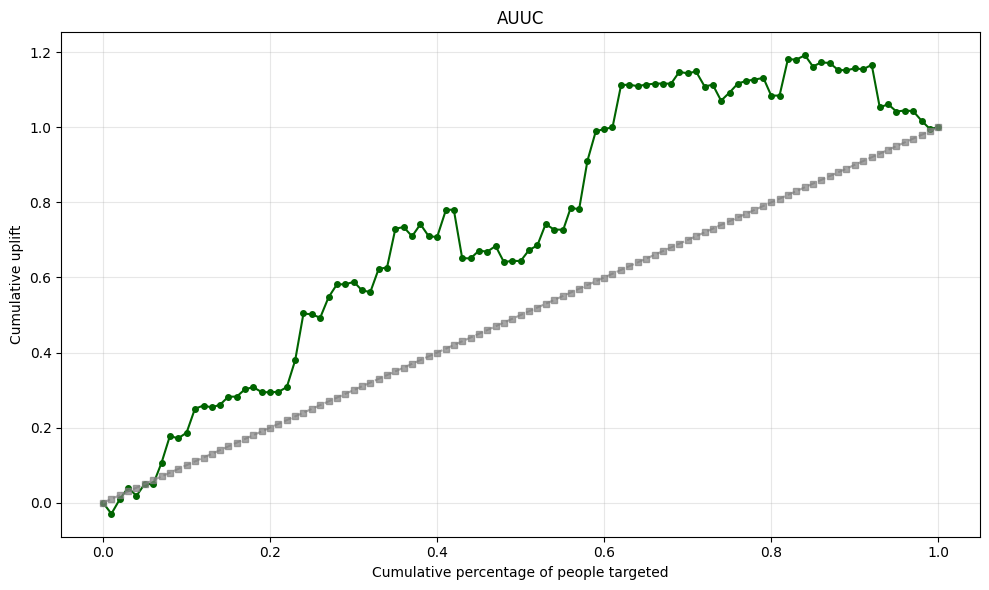

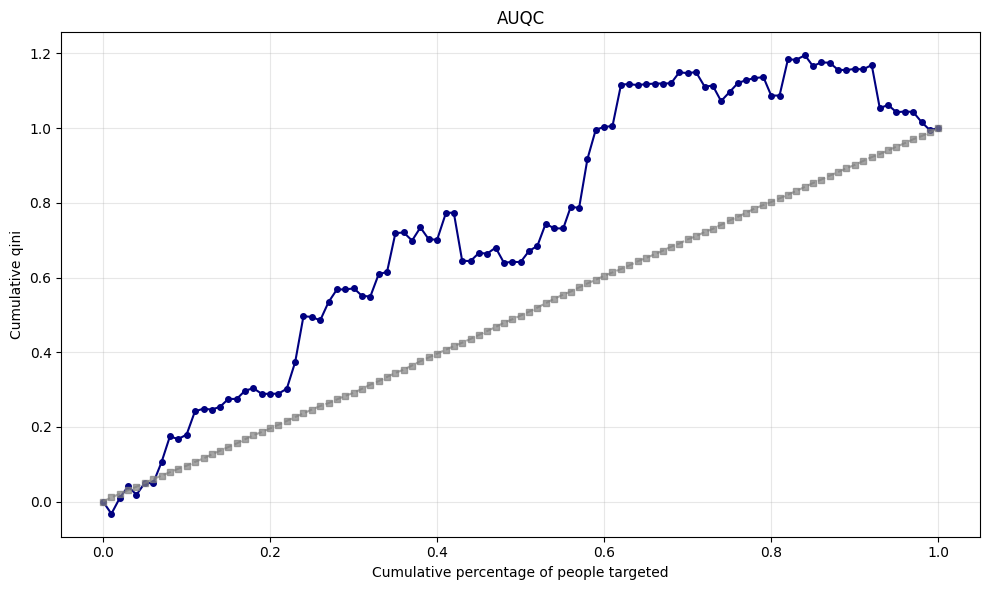

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.738
AUQC: 0.736
Lift: 1.153
KRCC: 0.160


In [43]:
seed = 902745
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_dropout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")

🔒 Locked Random Seed: 1
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 1
📊 Strategy: Two-Stage EMA Filter (alpha=0.05)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/150 | Base Loss: 53.3412 | Tarreg Loss: 362.842194 | Total Loss: 416.1833 | Val Loss: 48.8001 | Raw Qini: 0.4352 | EMA Trend: 0.4352 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/150 | Base Loss: 48.8513 | Tarreg Loss: 248.509995 | Total Loss: 297.3613 | Val Loss: 48.0540 | Raw Qini: 0.4749 | EMA Trend: 0.4372 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/150 | Base Loss: 50.4892 | Tarreg Loss: 277.474792 | Total Loss: 327.9640 | Val Loss: 47.2597 | Raw Qini: 0.5135 | EMA Trend: 0.4410 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/150 | Base Loss: 48.4494 | Tarreg Loss: 253.820984 | Total Loss: 302.2704 | Val Loss: 46.4160 | Raw Qini: 0.5138 | EMA Trend: 0.4447 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/150 | Base Loss: 44.0084 | Tarreg

/home/ducvu0904/Documents/Lab/RERUM/Dragonnet + ZILN/dragonnet.py:333: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


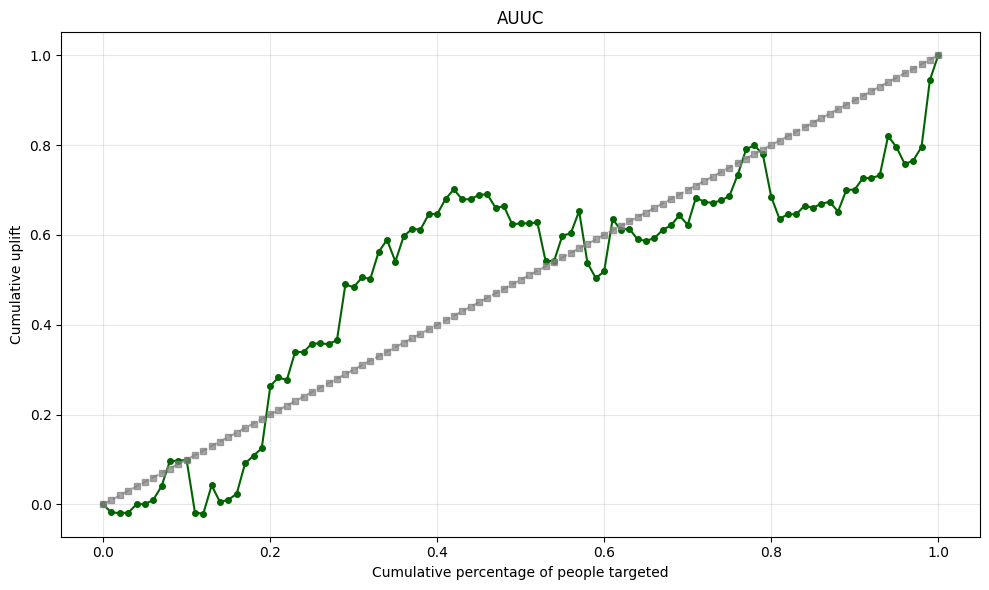

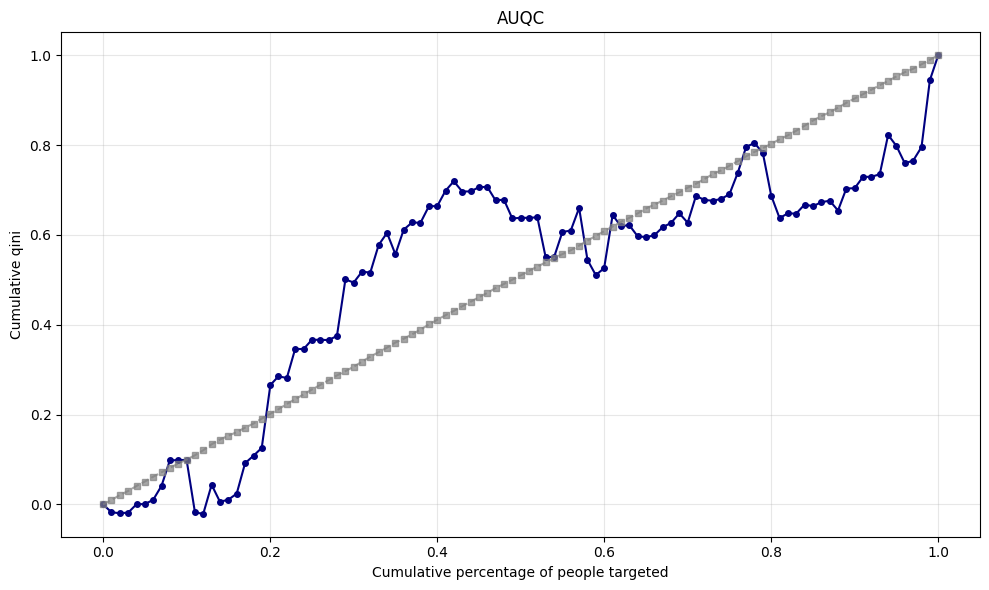

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.504
AUQC: 0.510
Lift: 0.947
KRCC: 0.021


In [44]:
seed = 1
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      alpha=alpha, 
                      beta= beta, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_dropout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch = early_stop_start
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")